In [ ]:
!pip install sentence-transformers scikit-learn xgboost textblob nltk pandas numpy matplotlib seaborn imbalanced-learn

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

from textblob import TextBlob
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
import csv
df = pd.read_csv("/content/dataset 2.csv", engine='python', on_bad_lines='warn', quoting=csv.QUOTE_NONE)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDecision value counts:\n{df['decision'].value_counts()}")
print(f"\nNull values:\n{df.isnull().sum()}")
df.head(3)

Shape: (523436, 8)

Columns: ['ID', 'Name', 'Role', 'Transcript', 'Resume', 'decision', 'Reason_for_decision', 'Job_Description']

Decision value counts:
decision
 of course                                                                                                                  155
 Graphs                                                                                                                     145
 cross-functional team."                                                                                                     99
 delivering solutions that shape the future."                                                                                98
select                                                                                                                       95
                                                                                                                           ... 
 that drove conversions and met business goals                       

,ID,Name,Role,Transcript,Resume,decision,Reason_for_decision,Job_Description
0,jasojo159,Jason Jones,E-commerce Specialist,"""Interviewer: Good morning",Jason. It's great to meet you. Welcome to the...,None,None,None
1,Jason Jones: Good morning. Thank you for havin...,None,None,None,None,None,None,None
2,Interviewer: Before we begin,I want to let you know that this interview wi...,including customer service,product listing,and other relevant topics. Can you start by t...,None,None,None


In [ ]:
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    """Aggressive but fast text cleaning pipeline."""
    if not isinstance(text, str) or text.strip() == "":
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)            # remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)                   # remove emails
    text = re.sub(r'\d{3}[-.\s]\d{3}[-.\s]\d{4}', ' ', text)  # remove phones
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)               # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()               # collapse whitespace
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 2]
    return " ".join(tokens)

# Apply cleaning
df['clean_resume']     = df['Resume'].fillna('').apply(clean_text)
df['clean_transcript'] = df['Transcript'].fillna('').apply(clean_text)
df['clean_jd']         = df['Job_Description'].fillna('').apply(clean_text)

# Verify
print("Sample cleaned resume:\n", df['clean_resume'].iloc[0][:200])
print("\nSample cleaned JD:\n", df['clean_jd'].iloc[0][:200])

Sample cleaned resume:
 jason great meet welcome interview commerce specialist role company

Sample cleaned JD:
 


In [ ]:
df['candidate_text'] = df['clean_resume'] + " " + df['clean_resume'] + " " + df['clean_transcript']

print("Candidate text sample:\n", df['candidate_text'].iloc[0][:300])

Candidate text sample:
 jason great meet welcome interview commerce specialist role company jason great meet welcome interview commerce specialist role company interviewer good morning


In [ ]:
print("Loading SBERT model...")
sbert = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding candidate texts (this may take a few minutes)...")
candidate_embeddings = sbert.encode(
    df['candidate_text'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Encoding JD texts...")
jd_embeddings = sbert.encode(
    df['clean_jd'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

df['candidate_emb'] = list(candidate_embeddings)
df['jd_emb']        = list(jd_embeddings)

print(f"\n Embeddings done. Shape: {candidate_embeddings.shape}")

Loading SBERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding candidate texts (this may take a few minutes)...


Batches:   0%|          | 0/8179 [00:00<?, ?it/s]

Encoding JD texts...


Batches:   0%|          | 0/8179 [00:00<?, ?it/s]


 Embeddings done. Shape: (523436, 384)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

Computing cosine similarity scores...
Match score stats:
count    523436.000000
mean         85.285950
std          33.194511
min         -17.946489
25%         100.000015
50%         100.000015
75%         100.000015
max         100.000015
Name: match_score, dtype: float64


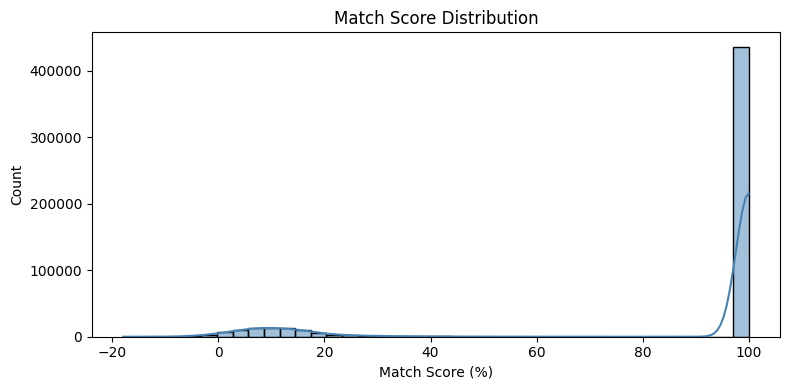

In [ ]:
print("Computing cosine similarity scores...")

match_scores = [
    cosine_similarity([candidate_embeddings[i]], [jd_embeddings[i]])[0][0]
    for i in range(len(df))
]

df['match_score'] = np.array(match_scores) * 100

print(f"Match score stats:\n{df['match_score'].describe()}")

# Distribution plot
plt.figure(figsize=(8, 4))
sns.histplot(df['match_score'], bins=40, kde=True, color='steelblue')
plt.title("Match Score Distribution")
plt.xlabel("Match Score (%)")
plt.tight_layout()
plt.show()

In [ ]:
SKILLS = [
    # Programming languages
    "python", "java", "javascript", "typescript", "scala", "r", "sql", "c++", "golang",
    # ML / AI
    "machine learning", "deep learning", "neural network", "nlp", "computer vision",
    "tensorflow", "pytorch", "keras", "scikit learn", "huggingface",
    # Data
    "pandas", "numpy", "spark", "hadoop", "kafka", "airflow", "dbt",
    "data analysis", "data engineering", "etl", "feature engineering",
    # Infra / Cloud
    "aws", "gcp", "azure", "docker", "kubernetes", "ci cd", "terraform",
    "microservices", "api", "rest", "graphql",
    # Soft / General
    "system design", "cloud", "agile", "leadership", "communication",
    "product management", "project management", "data visualization",
    "tableau", "power bi", "excel",
    # E-commerce / domain
    "ecommerce", "seo", "google analytics", "shopify", "digital marketing",
]

def extract_skills(text):
    return [skill for skill in SKILLS if skill in text]

df['candidate_skills'] = df['candidate_text'].apply(extract_skills)
df['jd_skills']        = df['clean_jd'].apply(extract_skills)

# Skill count features
df['num_candidate_skills'] = df['candidate_skills'].apply(len)
df['num_jd_skills']        = df['jd_skills'].apply(len)

print("Skills extracted. Sample:")
print("Candidate:", df['candidate_skills'].iloc[0])
print("JD:       ", df['jd_skills'].iloc[0])

Skills extracted. Sample:
Candidate: ['r']
JD:        []


In [ ]:
def skill_gap(row):
    missing = list(set(row['jd_skills']) - set(row['candidate_skills']))
    matched = list(set(row['jd_skills']) & set(row['candidate_skills']))
    return missing, matched

df['missing_skills'], df['matched_skills'] = zip(*df.apply(skill_gap, axis=1))

df['num_missing_skills'] = df['missing_skills'].apply(len)
df['num_matched_skills'] = df['matched_skills'].apply(len)

df['skill_match_ratio'] = df.apply(
    lambda r: r['num_matched_skills'] / r['num_jd_skills'] if r['num_jd_skills'] > 0 else 0,
    axis=1
)

print("Skill gap stats:")
print(df[['num_candidate_skills', 'num_jd_skills', 'num_missing_skills', 'skill_match_ratio']].describe())

Skill gap stats:
       num_candidate_skills  num_jd_skills  num_missing_skills  \
count         523436.000000  523436.000000       523436.000000   
mean               0.209758       0.013140            0.002678   
std                0.565671       0.134745            0.060537   
min                0.000000       0.000000            0.000000   
25%                0.000000       0.000000            0.000000   
50%                0.000000       0.000000            0.000000   
75%                0.000000       0.000000            0.000000   
max                9.000000       6.000000            5.000000   

       skill_match_ratio  
count       523436.00000  
mean             0.00941  
std              0.09471  
min              0.00000  
25%              0.00000  
50%              0.00000  
75%              0.00000  
max              1.00000  


In [26]:
import re
import numpy as np
from textblob import TextBlob


def communication_score(text):
    words = text.split()
    if len(words) < 5:
        return 0.0
    return len(set(words)) / len(words)

def confidence_score(text):
    if not text.strip():
        return 0.0
    return TextBlob(text).sentiment.polarity

def subjectivity_score(text):
    if not text.strip():
        return 0.0
    return TextBlob(text).sentiment.subjectivity

def tech_score(text):
    if not text.strip():
        return 0.0
    count = sum(1 for skill in SKILLS if skill in text)
    return count / len(SKILLS)

def response_length(text):
    return np.log1p(len(text.split()))

def sentence_complexity(text):
    sentences = re.split(r'[.!?]', text)
    sentences = [s for s in sentences if len(s.split()) > 2]
    if not sentences:
        return 0.0
    return np.mean([len(s.split()) for s in sentences])

df['comm_score']     = df['clean_transcript'].apply(communication_score)
df['conf_score']     = df['clean_transcript'].apply(confidence_score)
df['subj_score']     = df['clean_transcript'].apply(subjectivity_score)
df['tech_score']     = df['candidate_text'].apply(tech_score)
df['response_len']   = df['clean_transcript'].apply(response_length)
df['sentence_cmplx'] = df['clean_transcript'].apply(sentence_complexity)

print("Features computed")
print(df[['comm_score','conf_score','subj_score',
          'tech_score','response_len','sentence_cmplx']].describe())


FEATURE_COLS = [
    'match_score',
    'skill_match_ratio',
    'num_matched_skills',
    'num_missing_skills',
    'num_candidate_skills',
    'comm_score',
    'conf_score',
    'subj_score',
    'tech_score',
    'response_len',
    'sentence_cmplx',
]

from sklearn.preprocessing import LabelEncoder

print("\nRaw decision value counts (top 10):")
print(df['decision'].value_counts().head(10))

df['decision_clean'] = (
    df['decision']
    .fillna('unknown')
    .str.lower()
    .str.strip()
)

def consolidate_label(val):
    val = str(val)
    if any(w in val for w in ['select','hire','hired','shortlist','pass','accept']):
        return 'select'
    elif any(w in val for w in ['reject','decline','fail','not select','no']):
        return 'reject'
    else:
        return 'reject'

df['decision_clean'] = df['decision_clean'].apply(consolidate_label)

print("\nConsolidated value counts:")
print(df['decision_clean'].value_counts())

le = LabelEncoder()
df['label'] = le.fit_transform(df['decision_clean'])
print("\nLabel encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df[FEATURE_COLS].values
y = df['label'].values

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\nFeature matrix : {X.shape}")
print(f"Class balance  : {dict(zip(*np.unique(y, return_counts=True)))}")

Features computed
          comm_score     conf_score     subj_score     tech_score  \
count  523436.000000  523436.000000  523436.000000  523436.000000   
mean        0.073465       0.015821       0.034584       0.003680   
std         0.258827       0.093878       0.144972       0.009924   
min         0.000000      -1.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       0.000000   
50%         0.000000       0.000000       0.000000       0.000000   
75%         0.000000       0.000000       0.000000       0.000000   
max         1.000000       1.000000       1.000000       0.157895   

        response_len  sentence_cmplx  
count  523436.000000   523436.000000  
mean        0.272861        0.868962  
std         0.678635        3.097542  
min         0.000000        0.000000  
25%         0.000000        0.000000  
50%         0.000000        0.000000  
75%         0.000000        0.000000  
max         4.174387       64.000000  

Raw deci

In [24]:
print("Column names:")
print(df.columns.tolist())
print("\nFirst row, each column:")
for col in df.columns:
    val = str(df[col].iloc[0])
    print(f"  {col:30s} | {val[:80]}")

Column names:
['ID', 'Name', 'Role', 'Transcript', 'Resume', 'decision', 'Reason_for_decision', 'Job_Description', 'clean_resume', 'clean_transcript', 'clean_jd', 'candidate_text', 'candidate_emb', 'jd_emb', 'match_score', 'candidate_skills', 'jd_skills', 'num_candidate_skills', 'num_jd_skills', 'missing_skills', 'matched_skills', 'num_missing_skills', 'num_matched_skills', 'skill_match_ratio', 'comm_score', 'conf_score', 'subj_score', 'tech_score', 'response_len', 'sentence_cmplx', 'decision_clean', 'label']

First row, each column:
  ID                             | jasojo159
  Name                           | Jason Jones
  Role                           | E-commerce Specialist
  Transcript                     | "Interviewer: Good morning
  Resume                         |  Jason. It's great to meet you. Welcome to the interview for the E-commerce Spec
  decision                       | None
  Reason_for_decision            | None
  Job_Description                | None
  clean_resum

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Train size (after SMOTE): {X_train_res.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Training class balance: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")

Train size (after SMOTE): (835918, 11)
Test size:  (104688, 11)
Training class balance: {np.int64(0): np.int64(417959), np.int64(1): np.int64(417959)}


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_res, y_train_res)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1  = f1_score(y_test, lr_pred, average='weighted')
lr_auc = roc_auc_score(y_test, lr_prob)

print("  Model: Logistic Regression")
print(f"  Test Accuracy : {lr_acc:.4f}")
print(f"  F1 Score      : {lr_f1:.4f}")
print(f"  ROC-AUC       : {lr_auc:.4f}")
print(classification_report(y_test, lr_pred, target_names=le.classes_))

  Model: Logistic Regression
  Test Accuracy : 0.8495
  F1 Score      : 0.9168
  ROC-AUC       : 0.9628
              precision    recall  f1-score   support

      reject       1.00      0.85      0.92    104491
      select       0.01      1.00      0.02       197

    accuracy                           0.85    104688
   macro avg       0.51      0.92      0.47    104688
weighted avg       1.00      0.85      0.92    104688



  Model: Random Forest
  Test Accuracy : 0.8946
  F1 Score      : 0.9425
  ROC-AUC       : 0.9679
              precision    recall  f1-score   support

      reject       1.00      0.89      0.94    104491
      select       0.02      0.92      0.03       197

    accuracy                           0.89    104688
   macro avg       0.51      0.91      0.49    104688
weighted avg       1.00      0.89      0.94    104688



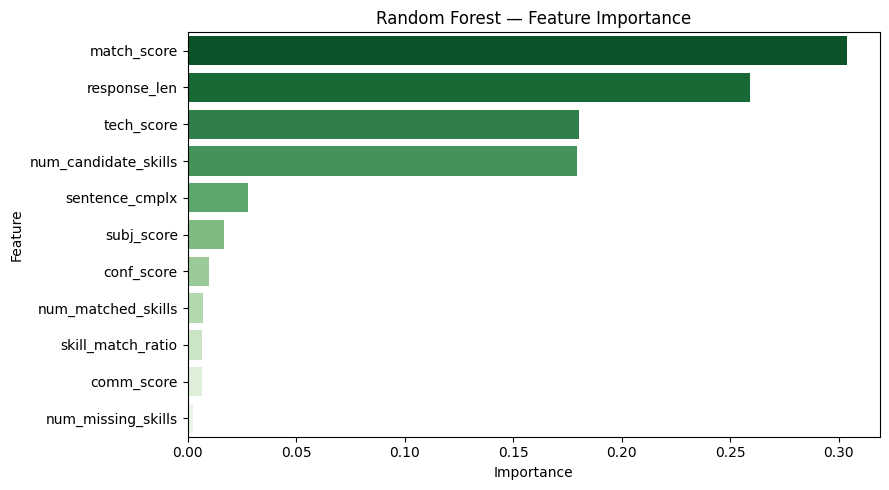

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred, average='weighted')
rf_auc = roc_auc_score(y_test, rf_prob)

print("  Model: Random Forest")
print(f"  Test Accuracy : {rf_acc:.4f}")
print(f"  F1 Score      : {rf_f1:.4f}")
print(f"  ROC-AUC       : {rf_auc:.4f}")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

# Feature importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feat_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='Greens_r')
plt.title("Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

  Model: XGBoost
  Test Accuracy : 0.9297
  F1 Score      : 0.9618
  ROC-AUC       : 0.9679
              precision    recall  f1-score   support

      reject       1.00      0.93      0.96    104491
      select       0.02      0.84      0.04       197

    accuracy                           0.93    104688
   macro avg       0.51      0.88      0.50    104688
weighted avg       1.00      0.93      0.96    104688



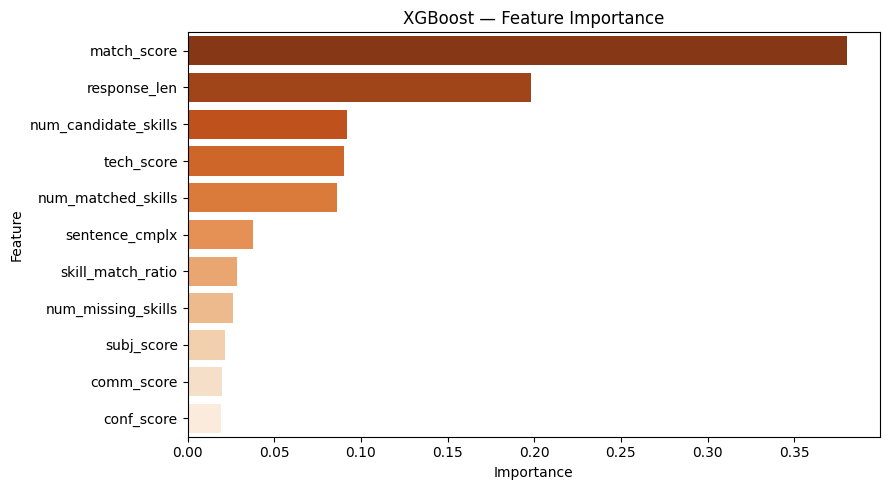

In [30]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1  = f1_score(y_test, xgb_pred, average='weighted')
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("  Model: XGBoost")
print(f"  Test Accuracy : {xgb_acc:.4f}")
print(f"  F1 Score      : {xgb_f1:.4f}")
print(f"  ROC-AUC       : {xgb_auc:.4f}")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

# Feature importance
feat_df_xgb = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df_xgb, x='Importance', y='Feature', palette='Oranges_r')
plt.title("XGBoost — Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)
svm_model.fit(X_train_res, y_train_res)

svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:, 1]

svm_acc = accuracy_score(y_test, svm_pred)
svm_f1  = f1_score(y_test, svm_pred, average='weighted')
svm_auc = roc_auc_score(y_test, svm_prob)

print("  Model: SVM (RBF Kernel)")
print(f"  Test Accuracy : {svm_acc:.4f}")
print(f"  F1 Score      : {svm_f1:.4f}")
print(f"  ROC-AUC       : {svm_auc:.4f}")
print(classification_report(y_test, svm_pred, target_names=le.classes_))

  Model: MLP Neural Network
  Test Accuracy : 0.9405
  F1 Score      : 0.9675
  ROC-AUC       : 0.9620
              precision    recall  f1-score   support

      reject       1.00      0.94      0.97    104491
      select       0.02      0.76      0.05       197

    accuracy                           0.94    104688
   macro avg       0.51      0.85      0.51    104688
weighted avg       1.00      0.94      0.97    104688



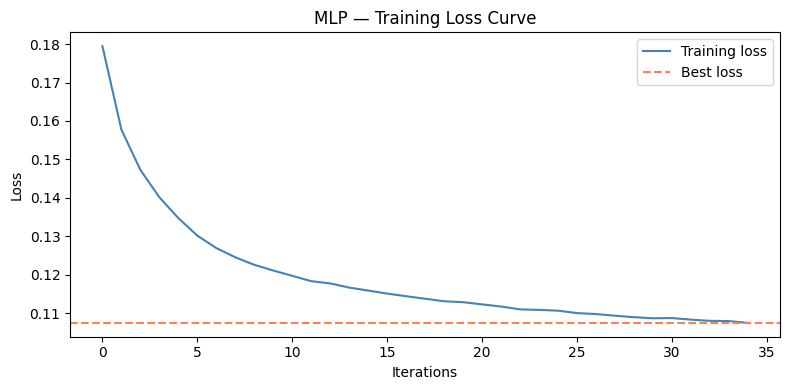

In [31]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp_model.fit(X_train_res, y_train_res)

mlp_pred = mlp_model.predict(X_test)
mlp_prob = mlp_model.predict_proba(X_test)[:, 1]

mlp_acc = accuracy_score(y_test, mlp_pred)
mlp_f1  = f1_score(y_test, mlp_pred, average='weighted')
mlp_auc = roc_auc_score(y_test, mlp_prob)

print("  Model: MLP Neural Network")
print(f"  Test Accuracy : {mlp_acc:.4f}")
print(f"  F1 Score      : {mlp_f1:.4f}")
print(f"  ROC-AUC       : {mlp_auc:.4f}")
print(classification_report(y_test, mlp_pred, target_names=le.classes_))

# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, color='steelblue', label='Training loss')
if mlp_model.best_validation_score_ is not None:
    plt.axhline(y=min(mlp_model.loss_curve_), color='coral',
                linestyle='--', label='Best loss')
plt.title("MLP — Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
import joblib
import os
import json
from datetime import datetime

SAVE_DIR = "ats_models"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Saving models to: {SAVE_DIR}/\n")

models_to_save = {
    "logistic_regression": lr_model,
    "random_forest":       rf_model,
    "xgboost":             xgb_model,
    "mlp_neural_net":      mlp_model,
}

for name, model in models_to_save.items():
    path = os.path.join(SAVE_DIR, f"{name}.pkl")
    joblib.dump(model, path)
    size_kb = os.path.getsize(path) / 1024
    print(f"  {name:<25} saved → {path}  ({size_kb:.1f} KB)")

joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler.pkl"))
joblib.dump(le,     os.path.join(SAVE_DIR, "label_encoder.pkl"))
print(f"\n  scaler.pkl           saved")
print(f"  label_encoder.pkl    saved")

metadata = {
    "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "feature_cols": FEATURE_COLS,
    "label_classes": le.classes_.tolist(),
    "model_scores": {
        "logistic_regression": {"accuracy": lr_acc,  "f1": lr_f1,  "roc_auc": lr_auc},
        "random_forest":       {"accuracy": rf_acc,  "f1": rf_f1,  "roc_auc": rf_auc},
        "xgboost":             {"accuracy": xgb_acc, "f1": xgb_f1, "roc_auc": xgb_auc},
        "mlp_neural_net":      {"accuracy": mlp_acc, "f1": mlp_f1, "roc_auc": mlp_auc},
    },
    "best_model": max(
        models_to_save.keys(),
        key=lambda m: metadata["model_scores"][m]["accuracy"]
        if "metadata" in dir() else 0
    ) if False else sorted(
        [
            ("logistic_regression", lr_acc),
            ("random_forest",       rf_acc),
            ("xgboost",             xgb_acc),
            ("mlp_neural_net",      mlp_acc),
        ],
        key=lambda x: x[1], reverse=True
    )[0][0]
}

meta_path = os.path.join(SAVE_DIR, "metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=4)
print(f"  metadata.json        saved")

print(f"  All files saved in → ./{SAVE_DIR}/")

for fname in sorted(os.listdir(SAVE_DIR)):
    size_kb = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1024
    print(f"  {fname:<30} {size_kb:>8.1f} KB")
print(f"\n  Best model: {metadata['best_model']}")

Saving models to: ats_models/

  logistic_regression       saved → ats_models/logistic_regression.pkl  (0.9 KB)
  random_forest             saved → ats_models/random_forest.pkl  (8194.4 KB)
  xgboost                   saved → ats_models/xgboost.pkl  (814.2 KB)
  mlp_neural_net            saved → ats_models/mlp_neural_net.pkl  (287.9 KB)

  scaler.pkl           saved
  label_encoder.pkl    saved
  metadata.json        saved
  All files saved in → ./ats_models/
  label_encoder.pkl                   0.5 KB
  logistic_regression.pkl             0.9 KB
  metadata.json                       1.1 KB
  mlp_neural_net.pkl                287.9 KB
  random_forest.pkl                8194.4 KB
  scaler.pkl                          0.8 KB
  xgboost.pkl                       814.2 KB

  Best model: mlp_neural_net


In [33]:
print("Loading models back from disk...\n")

loaded_models = {}
for name in models_to_save.keys():
    path = os.path.join(SAVE_DIR, f"{name}.pkl")
    loaded_models[name] = joblib.load(path)
    print(f" Loaded: {name}")

loaded_scaler = joblib.load(os.path.join(SAVE_DIR, "scaler.pkl"))
loaded_le     = joblib.load(os.path.join(SAVE_DIR, "label_encoder.pkl"))
print(f"  Loaded: scaler")
print(f"  Loaded: label_encoder")

print("\n Verification — predictions on test set:\n")
print(f"  {'Model':<25} {'Original Acc':>14} {'Reloaded Acc':>14} {'Match':>8}")
print(f"  {'-'*65}")

original_preds = {
    "logistic_regression": lr_pred,
    "random_forest":       rf_pred,
    "xgboost":             xgb_pred,
    "mlp_neural_net":      mlp_pred,
}

for name, model in loaded_models.items():
    reloaded_pred = model.predict(X_test)
    orig_acc      = accuracy_score(y_test, original_preds[name])
    reload_acc    = accuracy_score(y_test, reloaded_pred)
    match         = "Correct" if np.array_equal(original_preds[name], reloaded_pred) else "Incorrect"
    print(f"  {name:<25} {orig_acc:>14.4f} {reload_acc:>14.4f} {match:>8}")

print("\n All models verified successfully")

Loading models back from disk...

 Loaded: logistic_regression
 Loaded: random_forest
 Loaded: xgboost
 Loaded: mlp_neural_net
  Loaded: scaler
  Loaded: label_encoder

 Verification — predictions on test set:

  Model                       Original Acc   Reloaded Acc    Match
  -----------------------------------------------------------------
  logistic_regression               0.8495         0.8495  Correct
  random_forest                     0.8946         0.8946  Correct
  xgboost                           0.9297         0.9297  Correct
  mlp_neural_net                    0.9405         0.9405  Correct

 All models verified successfully


In [36]:
best_model = mlp_model

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=False)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f"Feature Importance — mlp_model")
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    coefs = np.abs(best_model.coef_[0])
    feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Coefficient': coefs})
    feat_df = feat_df.sort_values('Coefficient', ascending=False)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=feat_df, x='Coefficient', y='Feature', palette='coolwarm')
    plt.title(f"Feature Coefficients — mlp_model")
    plt.tight_layout()
    plt.show()

In [37]:
def final_decision(row):
    if row['match_score'] > 75 and row['skill_match_ratio'] > 0.5:
        return "SELECT"
    elif row['match_score'] > 55 and row['skill_match_ratio'] > 0.3:
        return "CONSIDER"
    else:
        return "REJECT"

df['rule_decision'] = df.apply(final_decision, axis=1)

X_all = scaler.transform(df[FEATURE_COLS].values)
df['ml_decision_encoded'] = best_model.predict(X_all)
df['ml_decision']         = le.inverse_transform(df['ml_decision_encoded'])
df['ml_confidence']       = best_model.predict_proba(X_all).max(axis=1) * 100

print("Decision distribution (Rule-based):")
print(df['rule_decision'].value_counts())
print("\nDecision distribution (ML):")
print(df['ml_decision'].value_counts())

Decision distribution (Rule-based):
rule_decision
REJECT      523294
CONSIDER       141
SELECT           1
Name: count, dtype: int64

Decision distribution (ML):
ml_decision
reject    490722
select     32714
Name: count, dtype: int64


In [38]:
def generate_explanation(row):
    parts = []

    if row['match_score'] >= 75:
        parts.append(f"Strong overall alignment with JD (match score: {row['match_score']:.1f}%).")
    elif row['match_score'] >= 55:
        parts.append(f"Moderate alignment with JD (match score: {row['match_score']:.1f}%).")
    else:
        parts.append(f"Low alignment with JD (match score: {row['match_score']:.1f}%).")

    if row['num_missing_skills'] == 0:
        parts.append("All required JD skills are present.")
    elif row['num_missing_skills'] <= 2:
        parts.append(f"Minor skill gap — missing: {', '.join(row['missing_skills'])}.")
    else:
        parts.append(f"Significant skill gaps — missing: {', '.join(row['missing_skills'][:5])}.")

    if row['comm_score'] >= 0.6:
        parts.append("Strong communication vocabulary diversity.")
    elif row['comm_score'] < 0.35:
        parts.append("Limited vocabulary diversity in interview responses.")

    if row['conf_score'] > 0.2:
        parts.append("Positive and confident tone in interview.")
    elif row['conf_score'] < -0.1:
        parts.append("Negative or uncertain tone detected in interview.")

    if row['tech_score'] > 0.4:
        parts.append("High technical keyword density.")
    elif row['tech_score'] < 0.15:
        parts.append("Low technical depth in responses.")

    return " ".join(parts)

df['explanation'] = df.apply(generate_explanation, axis=1)

print("Sample explanation:")
print(df['explanation'].iloc[0])

Sample explanation:
Low alignment with JD (match score: 15.8%). All required JD skills are present. Limited vocabulary diversity in interview responses. Positive and confident tone in interview. Low technical depth in responses.


In [46]:
OUTPUT_COLS = [
    'ID', 'Name', 'Role',
    'match_score', 'skill_match_ratio',
    'num_matched_skills', 'num_missing_skills',
    'comm_score', 'conf_score', 'tech_score',
    'ml_decision', 'ml_confidence',
    'rule_decision', 'explanation',
    'decision',
]

output_df = df[OUTPUT_COLS].copy()
output_df['match_score']       = output_df['match_score'].round(2)
output_df['skill_match_ratio'] = output_df['skill_match_ratio'].round(3)
output_df['ml_confidence']     = output_df['ml_confidence'].round(1)

output_df.to_csv("ats_output.csv", index=False)
print("Saved to ats_output.csv")

sample = output_df.iloc[0]
print(f"""
  Candidate:     {sample['Name']}
  Role:          {sample['Role']}
──────────────────────────────────────────
  Match Score:   {sample['match_score']}%
  Skills Matched:{sample['num_matched_skills']}  |  Missing: {sample['num_missing_skills']}
  Skill Ratio:   {sample['skill_match_ratio']}
──────────────────────────────────────────
  Communication: {sample['comm_score']:.3f}
  Confidence:    {sample['conf_score']:.3f}
  Technical:     {sample['tech_score']:.3f}
──────────────────────────────────────────
  ML Decision:   {sample['ml_decision'].upper()}  ({sample['ml_confidence']}% confident)
  Rule Decision: {sample['rule_decision']}
  Ground Truth:  {sample['decision']}
──────────────────────────────────────────
  Reason: {sample['explanation']}
""")


Saved to ats_output.csv

  Candidate:     Jason Jones
  Role:          E-commerce Specialist
──────────────────────────────────────────
  Match Score:   15.800000190734863%
  Skills Matched:0  |  Missing: 0
  Skill Ratio:   0.0
──────────────────────────────────────────
  Communication: 0.000
  Confidence:    0.700
  Technical:     0.018
──────────────────────────────────────────
  ML Decision:   REJECT  (100.0% confident)
  Rule Decision: REJECT
  Ground Truth:  None
──────────────────────────────────────────
  Reason: Low alignment with JD (match score: 15.8%). All required JD skills are present. Limited vocabulary diversity in interview responses. Positive and confident tone in interview. Low technical depth in responses.

